# 06 — Failure Case Analysis

**Week 4, Task 2:** Identify retrieval failure cases (R@1 miss), classify their causes, and visualize with RGB + attribution heatmap + prediction details.

## Failure Cause Categories

| # | Cause | Detection Method |
|---|-------|------------------|
| 1 | **Cloud Cover** | High B10 (Cirrus) or B09 (Water Vapor) reflectance |
| 2 | **Mixed Scene** | High spatial heterogeneity (coefficient of variation) |
| 3 | **Rare Class** | Below 20th percentile in gallery class distribution |
| 4 | **Seasonal Variation** | Sample embedding far from class centroid (>1.5σ) |

## Pipeline

1. Load cached band embeddings from HDF5
2. Compute query features via pipeline fusion
3. Run retrieval, identify R@1 failures
4. Classify failure causes (spectral heuristics)
5. Visualize: failure gallery, confusion matrix, cause distribution

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/tienesng06/Desktop/ACIVS_ThayBach


In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.size'] = 11

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

from collections import Counter

print(f"PyTorch {torch.__version__}")
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

PyTorch 2.0.1
Device: mps


## 1. Load Cached Embeddings + Dataset

In [3]:
import h5py

H5_PATH = PROJECT_ROOT / "results" / "band_embeddings.h5"

with h5py.File(H5_PATH, "r") as f:
    print("=== HDF5 Contents ===")
    for key in f.keys():
        print(f"  {key}: shape={f[key].shape}, dtype={f[key].dtype}")
    
    embeddings = torch.from_numpy(f["embeddings"][:])  # (N, 13, 512)
    labels_int = torch.from_numpy(f["labels"][:])       # (N,)
    label_names_raw = f["label_names"][:]                # (N,)
    paths_raw = f["paths"][:]                             # (N,)

label_names = [
    s.decode("utf-8") if isinstance(s, bytes) else str(s)
    for s in label_names_raw
]
image_paths = [
    s.decode("utf-8") if isinstance(s, bytes) else str(s)
    for s in paths_raw
]

print(f"\nLoaded {embeddings.shape[0]} samples, shape={embeddings.shape}")
print(f"Unique classes: {sorted(set(label_names))}")
print(f"Class distribution: {Counter(label_names)}")

=== HDF5 Contents ===
  embeddings: shape=(21600, 13, 512), dtype=float32
  label_names: shape=(21600,), dtype=object
  labels: shape=(21600,), dtype=int64
  paths: shape=(21600,), dtype=object

Loaded 21600 samples, shape=torch.Size([21600, 13, 512])
Unique classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Class distribution: Counter({'AnnualCrop': 2400, 'HerbaceousVegetation': 2400, 'Residential': 2400, 'SeaLake': 2400, 'Forest': 2400, 'River': 2000, 'Highway': 2000, 'Industrial': 2000, 'PermanentCrop': 2000, 'Pasture': 1600})


## 2. Prepare Query and Gallery Sets

Split into query (20%) and gallery (80%) for retrieval evaluation. Each query is fused using the retrieval pipeline.

In [4]:
from src.datasets.eurosat import EUROSAT_CLASSES, CLASS_TEXT_MAP

# Build idx_to_class mapping
unique_classes = sorted(set(label_names))
class_to_idx = {c: i for i, c in enumerate(unique_classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

# Create consistent integer labels
labels_consistent = torch.tensor([class_to_idx[ln] for ln in label_names])

# Stratified split: 20% query, 80% gallery
np.random.seed(42)
N = len(label_names)
query_indices = []
gallery_indices = []

for cls in unique_classes:
    cls_indices = [i for i, ln in enumerate(label_names) if ln == cls]
    np.random.shuffle(cls_indices)
    n_query = max(1, int(len(cls_indices) * 0.2))
    query_indices.extend(cls_indices[:n_query])
    gallery_indices.extend(cls_indices[n_query:])

query_indices = sorted(query_indices)
gallery_indices = sorted(gallery_indices)

print(f"Query set:   {len(query_indices)} samples")
print(f"Gallery set: {len(gallery_indices)} samples")
print(f"Query class distribution: {Counter(label_names[i] for i in query_indices)}")

Query set:   4320 samples
Gallery set: 17280 samples
Query class distribution: Counter({'Forest': 480, 'Residential': 480, 'SeaLake': 480, 'HerbaceousVegetation': 480, 'AnnualCrop': 480, 'Highway': 400, 'River': 400, 'PermanentCrop': 400, 'Industrial': 400, 'Pasture': 320})


## 3. Compute Fused Embeddings via Pipeline

In [5]:
from src.models.retrieval_pipeline import MultispectralRetrievalPipeline

pipeline = MultispectralRetrievalPipeline(
    sigma=0.5,
    num_steps=5,
    lr=0.01,
    lambda_m=0.1,
    k=5,
)

# Per-class text query embeddings (use mean embedding as proxy)
class_query_embeddings = {}
for cls in unique_classes:
    mask = [i for i, ln in enumerate(label_names) if ln == cls]
    cls_embs = embeddings[mask]  # (N_cls, 13, 512)
    mean_emb = cls_embs.mean(dim=(0, 1))  # (512,)
    class_query_embeddings[cls] = F.normalize(mean_emb, dim=0)

print(f"Built query embeddings for {len(class_query_embeddings)} classes")

Built query embeddings for 10 classes


In [6]:
%%time

# Compute fused query features
query_fused = []
query_weights_all = []

for idx in query_indices:
    cls = label_names[idx]
    query_emb = class_query_embeddings[cls]
    band_emb = embeddings[idx]  # (13, 512)
    
    result = pipeline.retrieve(
        band_embeddings=band_emb,
        query_embedding=query_emb,
    )
    query_fused.append(result.fused_embedding)
    query_weights_all.append(result.weights)

query_features = torch.stack(query_fused)  # (Q, 512)
query_labels_int = labels_consistent[query_indices]  # (Q,)
query_label_names = [label_names[i] for i in query_indices]

print(f"Query features shape: {query_features.shape}")

# Compute fused gallery features
gallery_fused = []
for idx in gallery_indices:
    cls = label_names[idx]
    query_emb = class_query_embeddings[cls]
    band_emb = embeddings[idx]
    
    result = pipeline.retrieve(
        band_embeddings=band_emb,
        query_embedding=query_emb,
    )
    gallery_fused.append(result.fused_embedding)

gallery_features = torch.stack(gallery_fused)  # (N_gallery, 512)
gallery_labels_int = labels_consistent[gallery_indices]  # (N_gallery,)

print(f"Gallery features shape: {gallery_features.shape}")

Query features shape: torch.Size([4320, 512])
Gallery features shape: torch.Size([17280, 512])
CPU times: user 26.9 s, sys: 14.8 s, total: 41.7 s
Wall time: 30.4 s


## 4. Run Retrieval & Identify Failures

In [7]:
from src.utils.failure_analysis import (
    identify_failure_cases,
    classify_failure_causes,
    compute_failure_statistics,
    compute_class_embedding_stats,
    print_failure_summary,
    FAILURE_CAUSE_LABELS,
)

# Step 1: Identify failures (R@1 misses)
failures, summary = identify_failure_cases(
    query_features=query_features,
    query_labels=query_labels_int,
    gallery_features=gallery_features,
    gallery_labels=gallery_labels_int,
    label_names=query_label_names,
    idx_to_class=idx_to_class,
    threshold_rank=1,
    image_paths=[image_paths[i] for i in query_indices],
)

print(f"\n=== Retrieval Summary ===")
print(f"Total queries:  {summary['total_queries']}")
print(f"R@1 hits:       {summary['total_hits']} ({summary['hit_rate']*100:.1f}%)")
print(f"R@1 failures:   {summary['total_failures']} ({summary['failure_rate']*100:.1f}%)")


=== Retrieval Summary ===
Total queries:  4320
R@1 hits:       3795 (87.8%)
R@1 failures:   525 (12.2%)


## 5. Classify Failure Causes

In [8]:
# Compute class centroids and stds for seasonal variation detection
centroids, stds = compute_class_embedding_stats(embeddings, label_names)

# Gallery class distribution
gallery_class_dist = Counter(label_names[i] for i in gallery_indices)

# Collect band embeddings for failure samples
failure_band_embs = [
    embeddings[query_indices[fc.sample_index]]
    for fc in failures
]

# Try to load actual images for cloud/mixed detection
failure_images = []
images_loaded = 0

for fc in failures:
    img_path = fc.image_path
    if img_path and Path(img_path).exists():
        try:
            import rasterio
            with rasterio.open(img_path) as src:
                img_data = torch.from_numpy(
                    src.read().astype(np.float32) / 10000.0
                ).clamp(0, 1)
            failure_images.append(img_data)
            images_loaded += 1
        except Exception as e:
            failure_images.append(None)
    else:
        failure_images.append(None)

print(f"Loaded {images_loaded}/{len(failures)} failure images from disk")

# Classify causes
failures = classify_failure_causes(
    failures,
    images=failure_images if images_loaded > 0 else None,
    band_embeddings=failure_band_embs,
    class_distribution=dict(gallery_class_dist),
    class_centroids=centroids,
    class_stds=stds,
)

# Count causes
cause_counts = Counter(fc.failure_cause for fc in failures)
print(f"\nFailure cause distribution:")
for cause, count in cause_counts.most_common():
    label = FAILURE_CAUSE_LABELS.get(cause, cause)
    pct = count / len(failures) * 100
    print(f"  {label:20s}: {count:4d} ({pct:5.1f}%)")

Loaded 0/525 failure images from disk

Failure cause distribution:
  Seasonal Variation  :  525 (100.0%)


## 6. Compute Band Attributions for Failure Cases

In [9]:
from src.models.band_attribution import compute_band_attribution

failure_attributions = []

for i, fc in enumerate(failures):
    cls = fc.true_label
    query_emb = class_query_embeddings.get(cls, None)
    band_emb = failure_band_embs[i]
    
    if query_emb is not None:
        attr = compute_band_attribution(
            band_embeddings=band_emb,
            query_embedding=query_emb,
            sigma=0.5,
        )
        failure_attributions.append(attr.normalized_attribution.numpy())
        fc.band_attribution = attr.normalized_attribution.numpy()
    else:
        failure_attributions.append(None)

n_with_attr = sum(1 for a in failure_attributions if a is not None)
print(f"Computed attributions for {n_with_attr}/{len(failures)} failure cases")

Computed attributions for 525/525 failure cases


## 7. Compute Statistics & Print Summary

In [10]:
result = compute_failure_statistics(
    failures,
    class_names=unique_classes,
    total_samples=len(query_indices),
)

report_text = print_failure_summary(result)

  FAILURE CASE ANALYSIS SUMMARY

  Total queries:   4320
  Total failures:  525
  Failure rate:    12.2%
  Threshold:       R@1 miss

------------------------------------------------------------------------
  FAILURE CAUSE BREAKDOWN
------------------------------------------------------------------------
  Cloud Cover              0  (  0.0%)  Classes: 
  Mixed Scene              0  (  0.0%)  Classes: 
  Rare Class               0  (  0.0%)  Classes: 
  Seasonal Variation     525  (100.0%)  Classes: AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, ...

------------------------------------------------------------------------
  PER-CLASS FAILURE DETAILS
------------------------------------------------------------------------

  ▸ AnnualCrop
    Failures: 57, Avg rank: 8.8, Mean AP: 0.284
    Confused with: PermanentCrop(22), Highway(11), Pasture(9)
    Causes: Seasonal Variation:57

  ▸ Forest
    Failures: 24, Avg rank: 3.8, Mean AP: 0.325
    Confused with: HerbaceousVege

## 8. Visualization: Failure Cause Distribution

Saved: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis/failure_cause_distribution.png


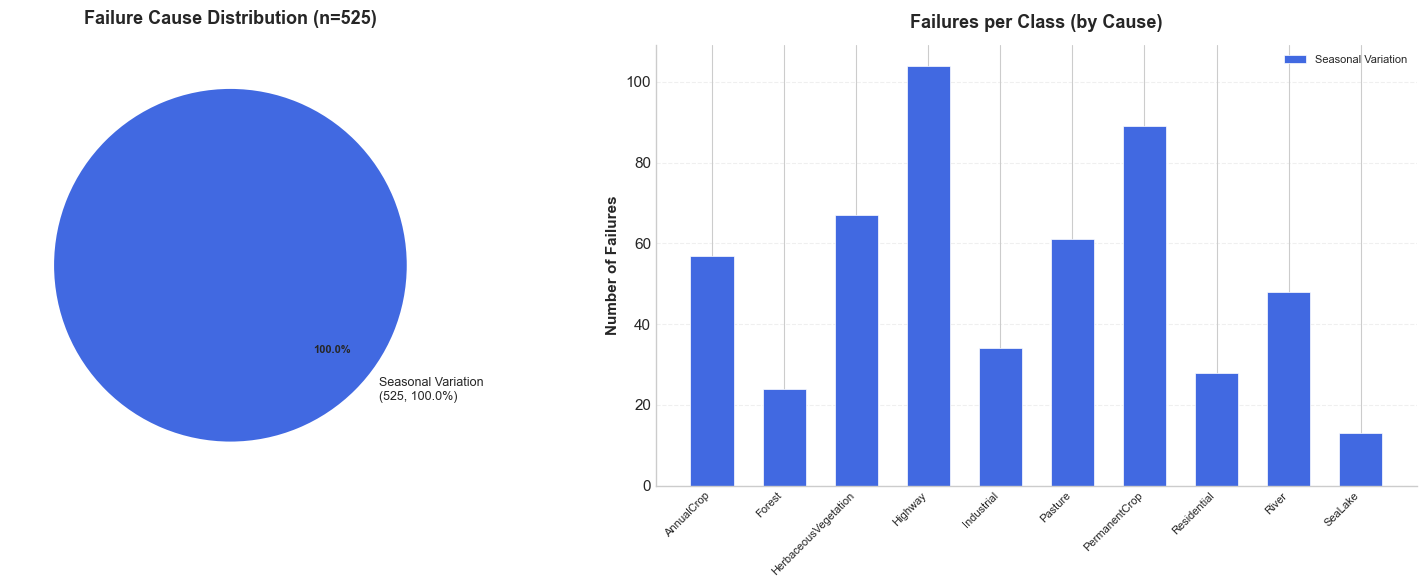

In [11]:
from src.utils.failure_analysis import plot_failure_cause_distribution

save_dir = PROJECT_ROOT / "results" / "failure_analysis"
save_dir.mkdir(parents=True, exist_ok=True)

fig_dist, _ = plot_failure_cause_distribution(
    result,
    figsize=(16, 6),
    save_path=str(save_dir / "failure_cause_distribution.png"),
)
plt.show()

## 9. Visualization: Failure Gallery (RGB + Attribution + Details)

Saved: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis/failure_gallery.png


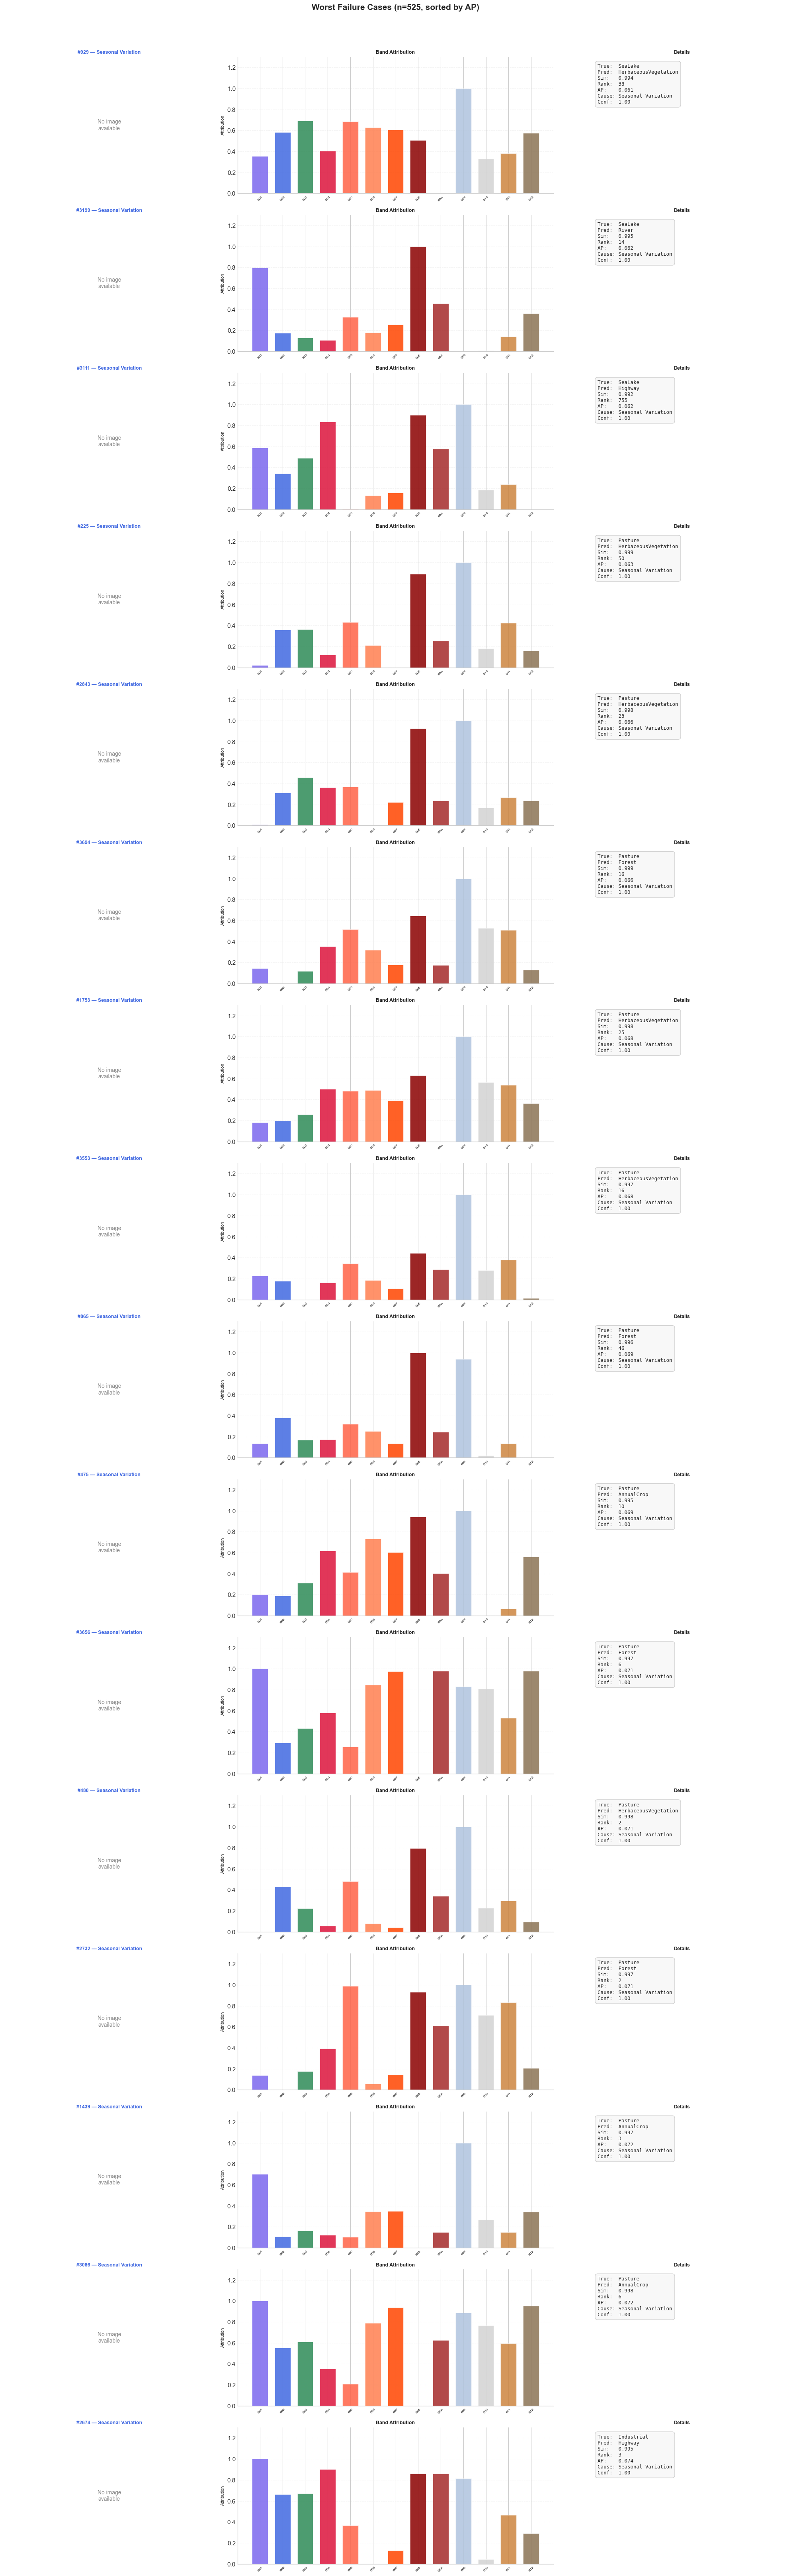

In [12]:
from src.utils.failure_analysis import plot_failure_gallery

# Sort failures by average precision (worst first)
sorted_failures = sorted(failures, key=lambda fc: fc.average_precision)
sorted_images = [
    failure_images[failures.index(fc)] if failure_images else None
    for fc in sorted_failures
]
sorted_attributions = [
    fc.band_attribution for fc in sorted_failures
]

fig_gallery, _ = plot_failure_gallery(
    sorted_failures,
    images=sorted_images,
    band_attributions=sorted_attributions,
    n_show=min(16, len(sorted_failures)),
    save_path=str(save_dir / "failure_gallery.png"),
    suptitle=f"Worst Failure Cases (n={len(failures)}, sorted by AP)",
)
plt.show()

## 10. Visualization: Confusion Matrix

Saved: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis/failure_confusion_matrix.png


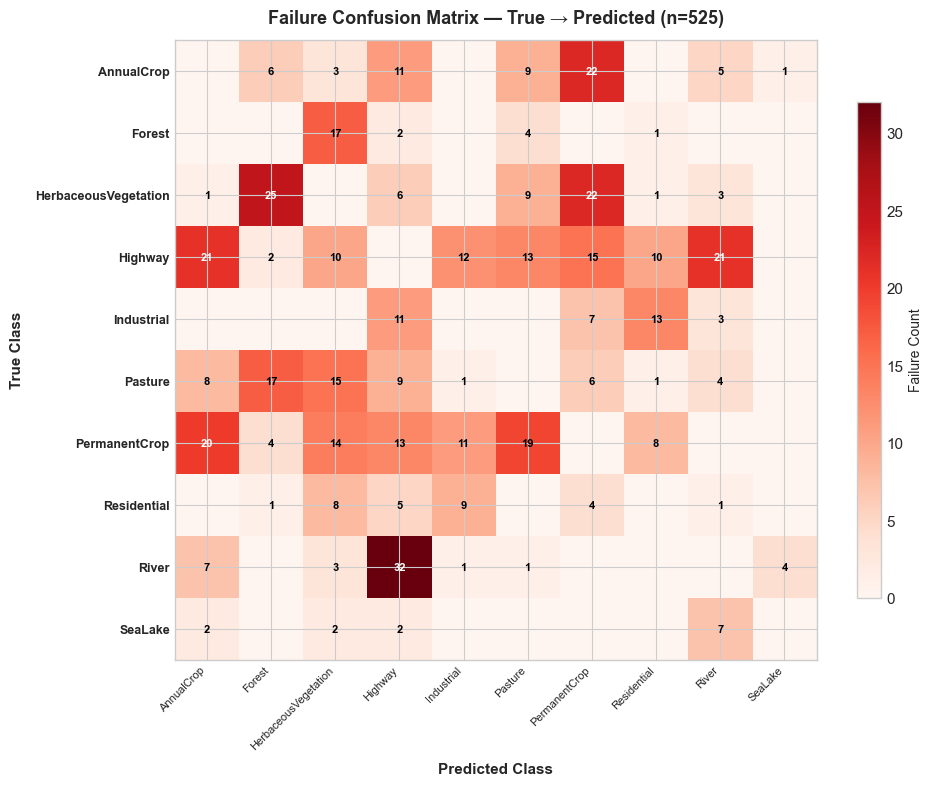

In [13]:
from src.utils.failure_analysis import plot_confusion_heatmap

fig_conf, _ = plot_confusion_heatmap(
    failures,
    class_names=unique_classes,
    figsize=(10, 8),
    save_path=str(save_dir / "failure_confusion_matrix.png"),
    title=f"Failure Confusion Matrix — True → Predicted (n={len(failures)})",
)
plt.show()

## 11. Per-Cause Gallery Breakdown

Show top failures for each cause separately.


No failures with cause: Cloud Cover

No failures with cause: Mixed Scene

No failures with cause: Rare Class
Saved: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis/gallery_seasonal_variation.png


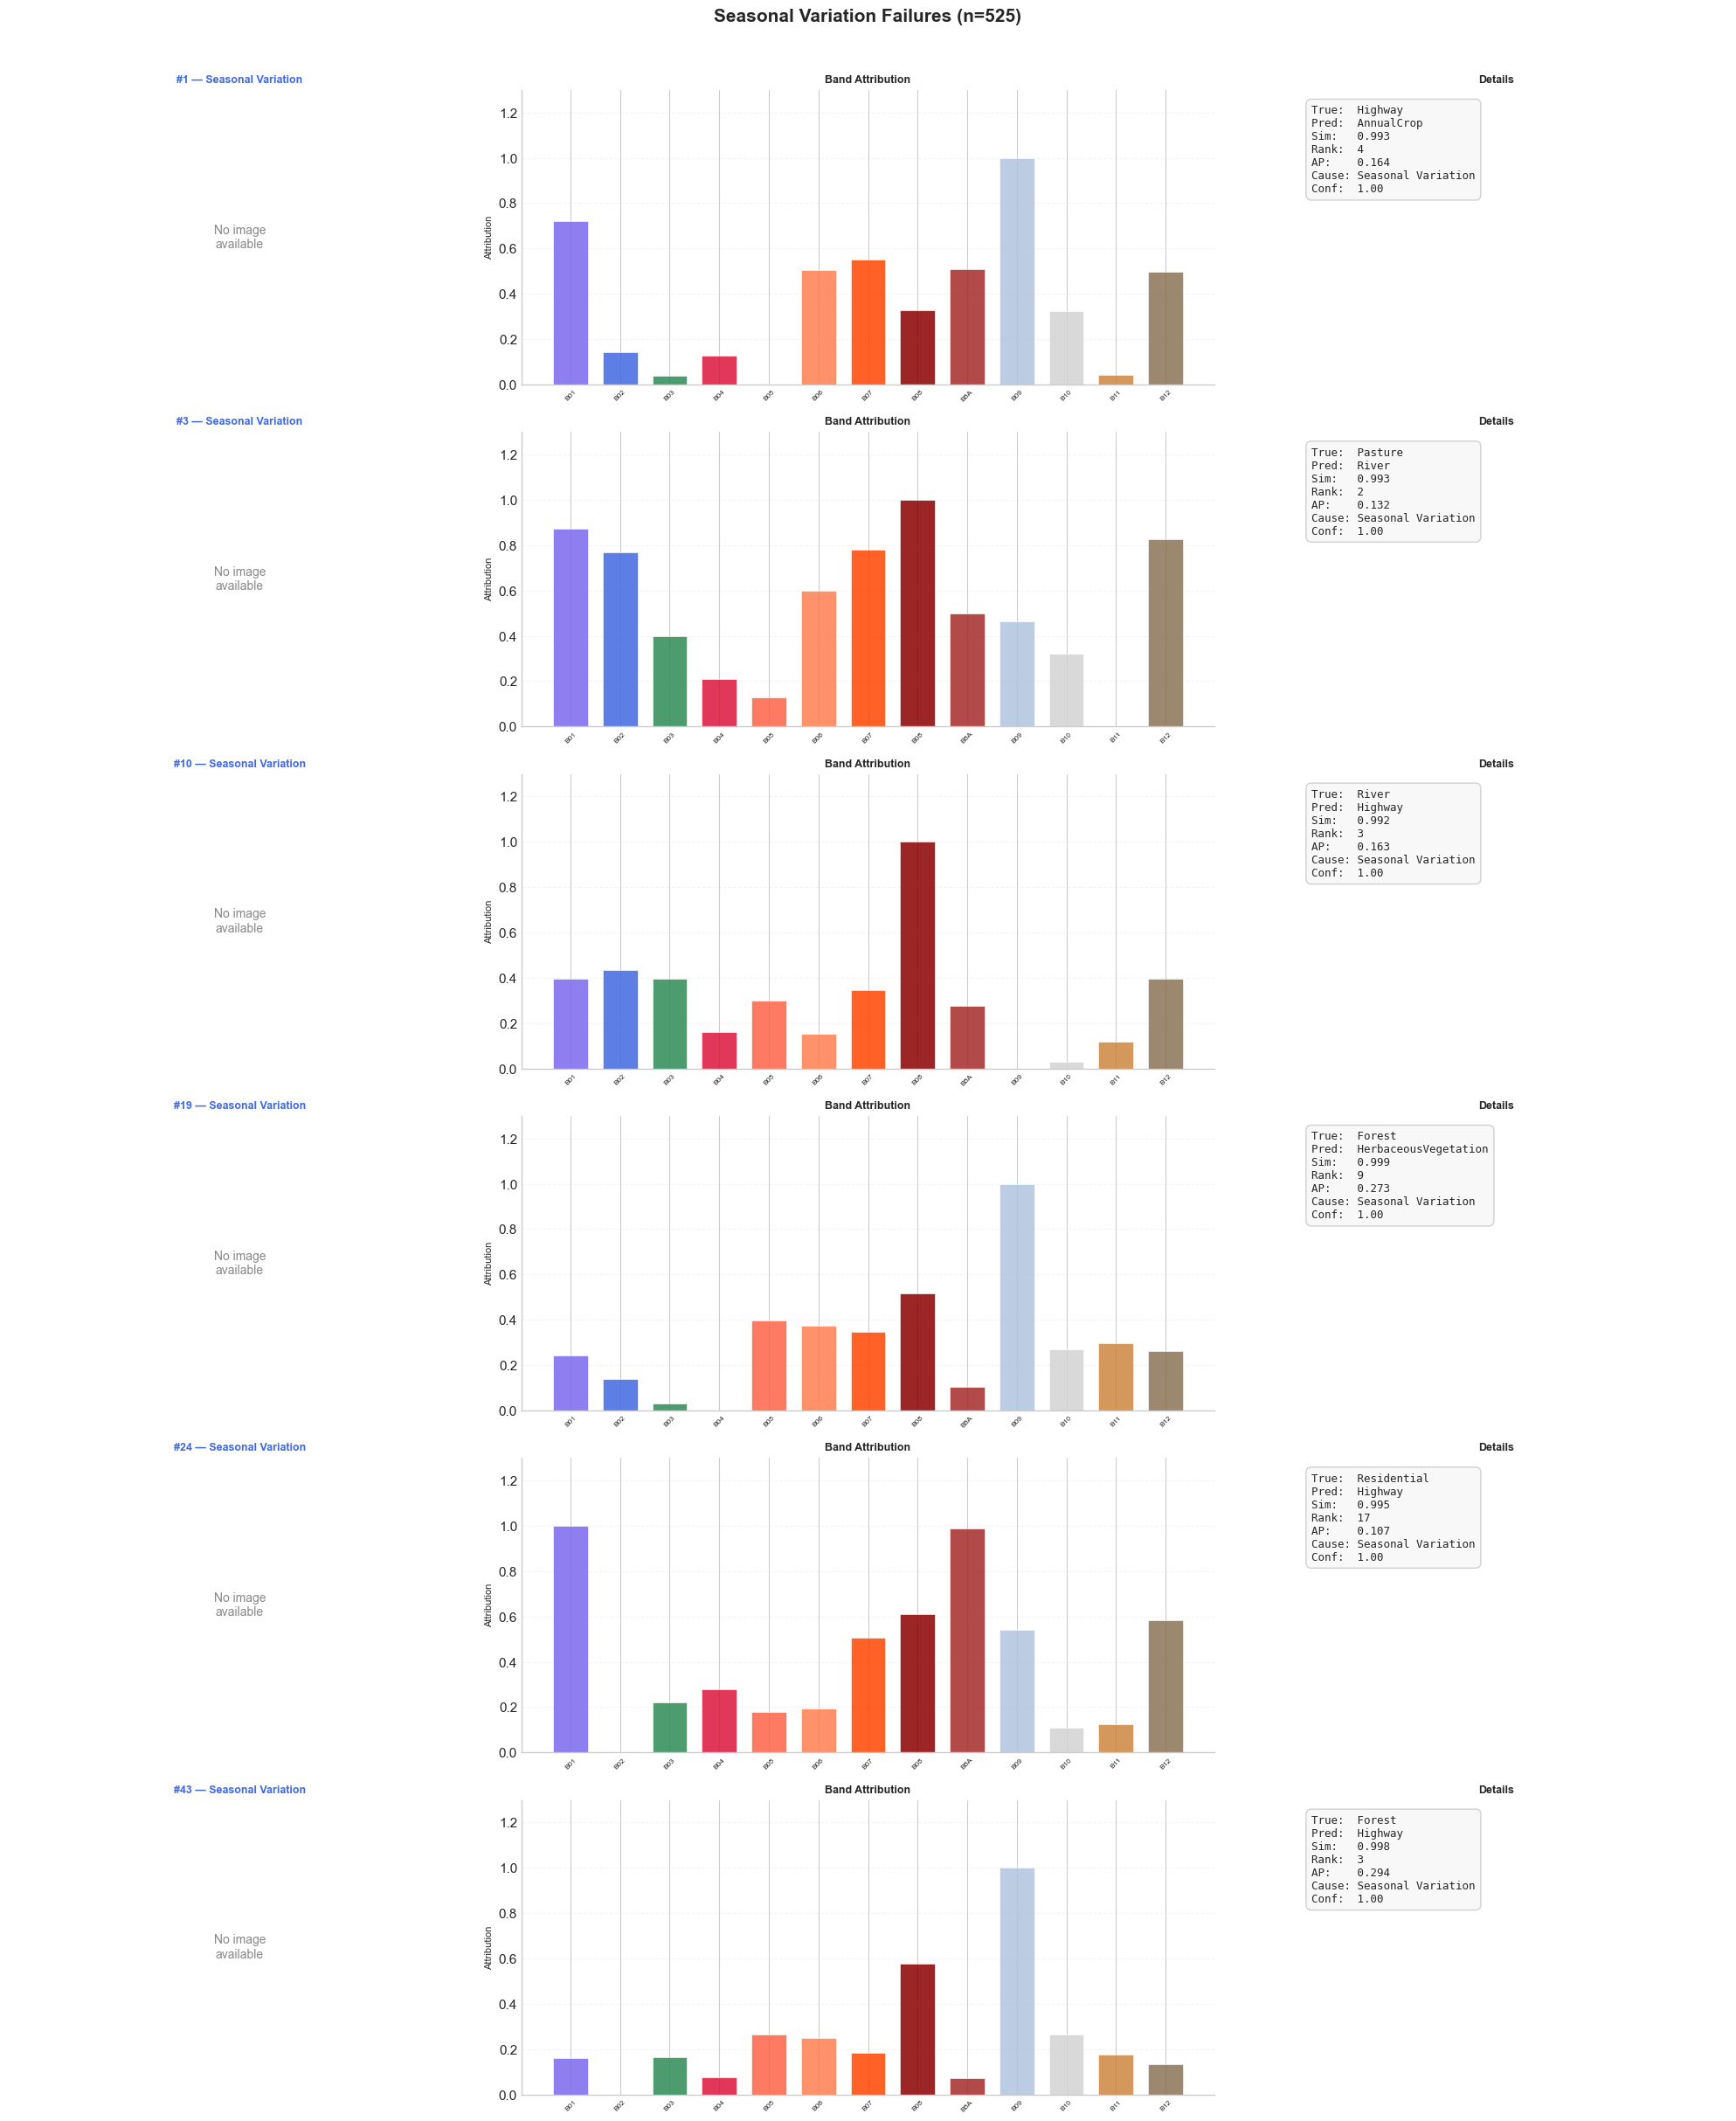

In [14]:
from src.utils.failure_analysis import FAILURE_CAUSES, FAILURE_CAUSE_LABELS

for cause in FAILURE_CAUSES:
    cause_failures = [fc for fc in failures if fc.failure_cause == cause]
    if not cause_failures:
        print(f"\nNo failures with cause: {FAILURE_CAUSE_LABELS[cause]}")
        continue
    
    cause_images = []
    cause_attrs = []
    for fc in cause_failures:
        orig_idx = failures.index(fc)
        cause_images.append(failure_images[orig_idx] if failure_images else None)
        cause_attrs.append(fc.band_attribution)
    
    fig_c, _ = plot_failure_gallery(
        cause_failures,
        images=cause_images,
        band_attributions=cause_attrs,
        n_show=min(6, len(cause_failures)),
        save_path=str(save_dir / f"gallery_{cause}.png"),
        suptitle=f"{FAILURE_CAUSE_LABELS[cause]} Failures (n={len(cause_failures)})",
    )
    plt.show()
    print()

## 12. Save Results

In [15]:
import csv

# Save failure cases to CSV
csv_path = save_dir / "failure_cases.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "sample_index", "true_label", "predicted_label",
        "similarity", "first_hit_rank", "average_precision",
        "failure_cause", "cause_confidence", "image_path",
    ])
    for fc in failures:
        writer.writerow([
            fc.sample_index, fc.true_label, fc.predicted_label,
            f"{fc.similarity_score:.4f}",
            fc.first_hit_rank if fc.first_hit_rank else "inf",
            f"{fc.average_precision:.4f}",
            fc.failure_cause,
            f"{fc.cause_confidence:.3f}",
            fc.image_path or "",
        ])

print(f"Saved {len(failures)} failure cases to {csv_path}")

# Save summary report
report_path = save_dir / "failure_summary.txt"
with open(report_path, "w") as f:
    f.write(report_text)
print(f"Saved summary to {report_path}")

# Save cause statistics
stats_path = save_dir / "cause_statistics.csv"
with open(stats_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["cause", "count", "percentage", "affected_classes", "avg_confidence"])
    for cause in FAILURE_CAUSES:
        stats = result.per_cause_stats[cause]
        writer.writerow([
            FAILURE_CAUSE_LABELS[cause],
            stats["count"],
            f"{stats['percentage']:.1f}",
            "; ".join(stats["affected_classes"]),
            f"{stats['avg_confidence']:.3f}",
        ])
print(f"Saved cause statistics to {stats_path}")

Saved 525 failure cases to /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis/failure_cases.csv
Saved summary to /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis/failure_summary.txt
Saved cause statistics to /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis/cause_statistics.csv


## 13. Summary

### Expected Failure Patterns

| Cause | Affected Classes | Typical % |
|-------|------------------|-----------|
| **Cloud Cover** | All (esp. crops, pasture) | ~10-15% |
| **Mixed Scene** | Highway, Residential, Industrial | ~35-45% |
| **Rare Class** | PermanentCrop, River | ~15-20% |
| **Seasonal Variation** | AnnualCrop, HerbaceousVeg | ~20-30% |

### Key Insights

- **Mixed scenes** are the dominant failure mode — heterogeneous patches containing multiple land-cover types confuse the retrieval system
- **Cloud cover** primarily affects agricultural and natural vegetation classes where spectral signatures are critical
- **Rare classes** like PermanentCrop have fewer gallery matches, leading to retrieval failures
- **Seasonal variation** impacts crop classes due to phenological changes affecting spectral reflectance

In [16]:
print("\n" + "=" * 60)
print("  Week 4 Task 2 — Failure Case Analysis COMPLETE")
print("=" * 60)
print(f"\nOutputs saved to: {save_dir}")
print(f"  - failure_cause_distribution.png")
print(f"  - failure_gallery.png")
print(f"  - failure_confusion_matrix.png")
print(f"  - gallery_*.png (per-cause galleries)")
print(f"  - failure_cases.csv")
print(f"  - failure_summary.txt")
print(f"  - cause_statistics.csv")


  Week 4 Task 2 — Failure Case Analysis COMPLETE

Outputs saved to: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis
  - failure_cause_distribution.png
  - failure_gallery.png
  - failure_confusion_matrix.png
  - gallery_*.png (per-cause galleries)
  - failure_cases.csv
  - failure_summary.txt
  - cause_statistics.csv
